# E-Commerce Customer & Delivery Analysis
## Olist Brazilian E-Commerce Dataset

**Objective:** Analyze 100K+ orders to uncover customer satisfaction drivers and delivery performance bottlenecks.

**Author:** Xiaodong Liu | IBM Certified Data Analyst

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load all datasets
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')

print(f'Orders: {orders.shape}')
print(f'Order Items: {order_items.shape}')
print(f'Products: {products.shape}')
print(f'Customers: {customers.shape}')
print(f'Reviews: {reviews.shape}')
print(f'Payments: {payments.shape}')
print(f'Sellers: {sellers.shape}')

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Reviews: (99224, 7)
Payments: (103886, 5)
Sellers: (3095, 4)


## 2. Data Cleaning & Preparation

In [3]:
# Check missing values
print('=== Orders Missing Values ===')
print(orders.isnull().sum())
print(f'\nTotal rows: {len(orders)}')

=== Orders Missing Values ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Total rows: 99441


In [4]:
# Convert date columns
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Create time features
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_dayofweek'] = orders['order_purchase_timestamp'].dt.day_name()

# Calculate delivery time (days)
orders['delivery_days'] = (orders['order_delivered_customer_date'] - 
                           orders['order_purchase_timestamp']).dt.days

# Is late delivery?
orders['is_late'] = (orders['order_delivered_customer_date'] > 
                     orders['order_estimated_delivery_date']).astype(int)

print('Date columns converted.')
print(f'Average delivery time: {orders["delivery_days"].mean():.1f} days')
print(f'Late delivery rate: {orders["is_late"].mean():.1%}')

Date columns converted.
Average delivery time: 12.1 days
Late delivery rate: 7.9%


In [5]:
# Merge tables into one analysis-ready dataset
df = (orders
      .merge(order_items, on='order_id', how='left')
      .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
      .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
      .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
      .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
)

# Drop rows without delivery date (not yet delivered)
df = df.dropna(subset=['order_delivered_customer_date'])

print(f'Merged dataset: {df.shape}')
df.head()

Merged dataset: (110839, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_year,...,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,customer_state,customer_city,review_score,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,2017,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,SP,sao paulo,4.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,2018,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,BA,barreiras,4.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,2018,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,GO,vianopolis,5.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,2017,...,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,RN,sao goncalo do amarante,5.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2018,...,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,SP,santo andre,5.0,28.62


## 3. Sales & Revenue Analysis

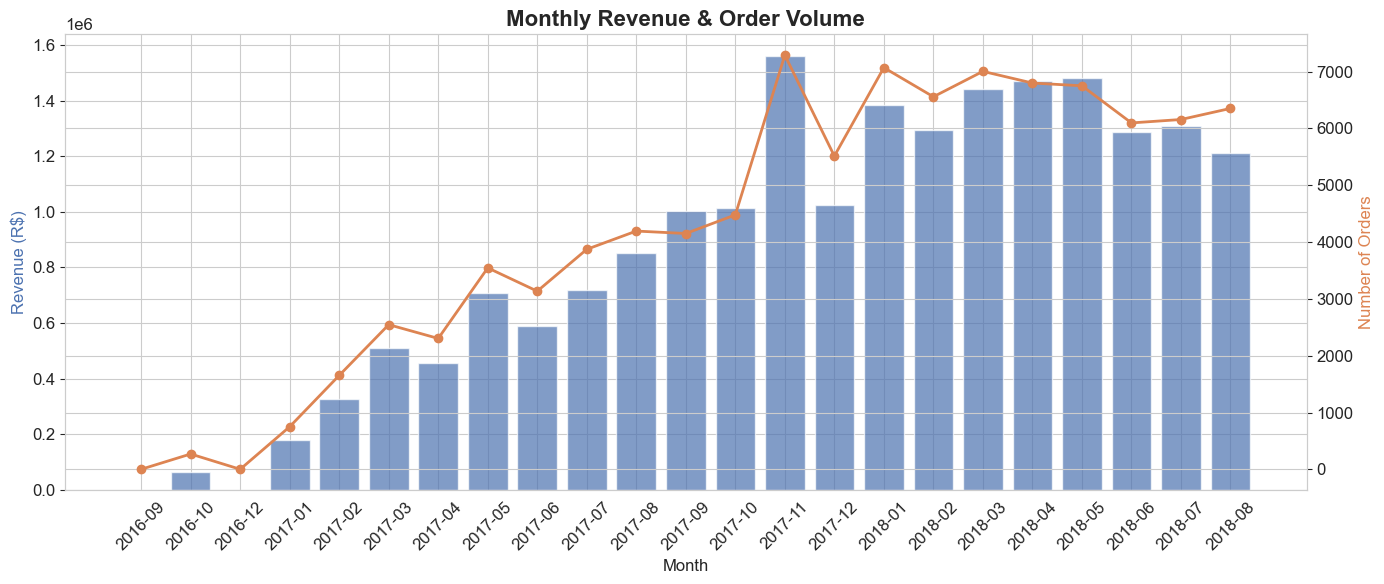

In [6]:
# Monthly order volume and revenue
monthly = (df.groupby('order_month')
           .agg(order_count=('order_id', 'nunique'),
                revenue=('payment_value', 'sum'))
           .reset_index())

monthly['order_month'] = monthly['order_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(monthly['order_month'], monthly['revenue'], color='#4C72B0', alpha=0.7, label='Revenue (R$)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (R$)', color='#4C72B0')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly['order_month'], monthly['order_count'], color='#DD8452', linewidth=2, marker='o', label='Orders')
ax2.set_ylabel('Number of Orders', color='#DD8452')

plt.title('Monthly Revenue & Order Volume', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

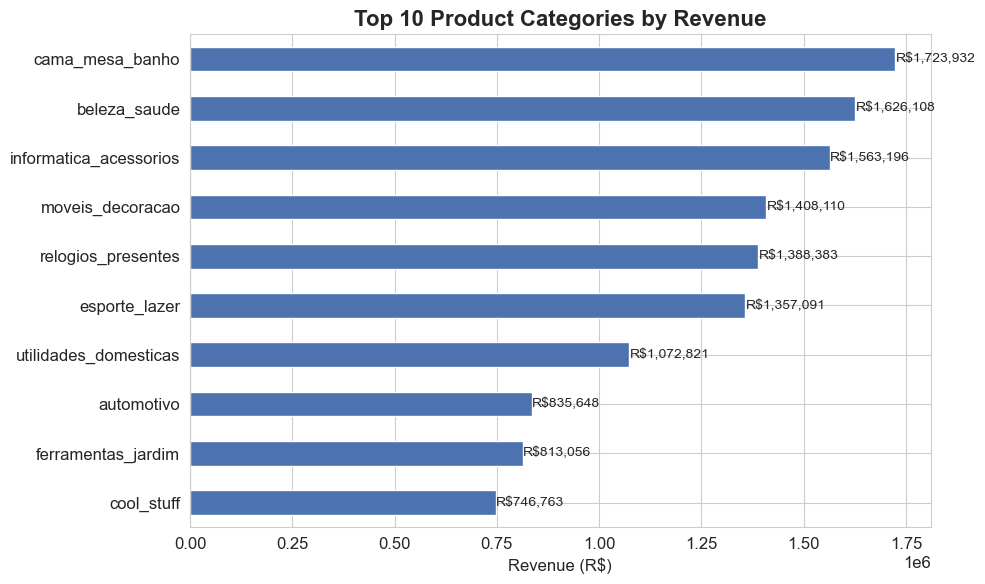

In [7]:
# Top 10 product categories by revenue
top_categories = (df.groupby('product_category_name')['payment_value']
                  .sum()
                  .sort_values(ascending=True)
                  .tail(10))

fig, ax = plt.subplots(figsize=(10, 6))
top_categories.plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_xlabel('Revenue (R$)')
ax.set_ylabel('')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')

for i, v in enumerate(top_categories.values):
    ax.text(v + 1000, i, f'R${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Delivery Performance Analysis

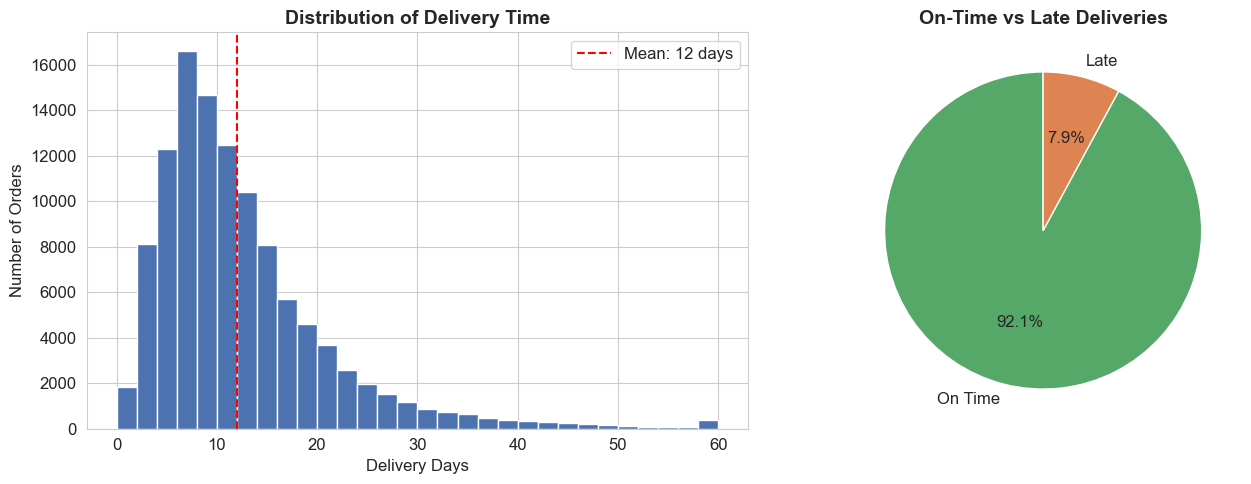

In [8]:
# Delivery time distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of delivery days
df['delivery_days'].clip(upper=60).hist(bins=30, ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].axvline(df['delivery_days'].mean(), color='red', linestyle='--', label=f'Mean: {df["delivery_days"].mean():.0f} days')
axes[0].set_title('Distribution of Delivery Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# On-time vs Late
late_counts = df['is_late'].value_counts()
labels = ['On Time', 'Late']
colors = ['#55A868', '#DD8452']
axes[1].pie(late_counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('On-Time vs Late Deliveries', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()

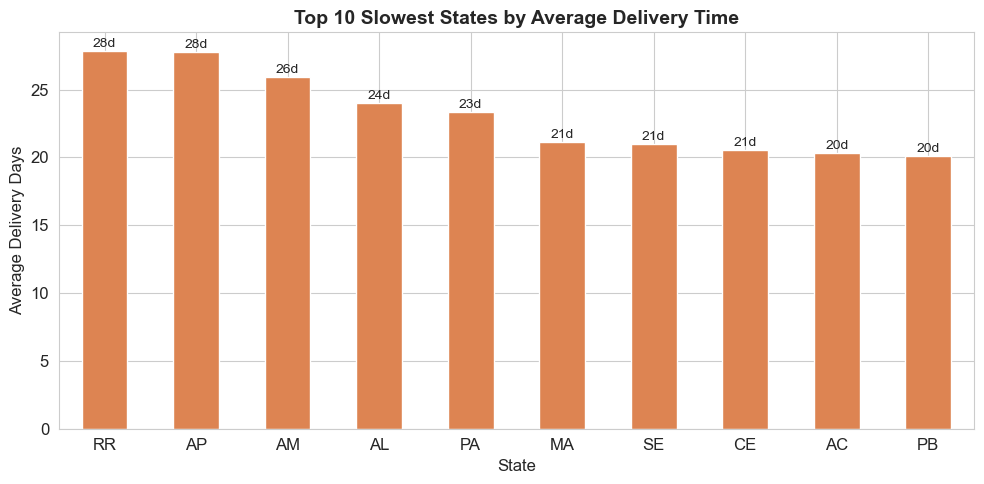

In [9]:
# Average delivery time by state (Top 10 slowest)
state_delivery = (df.groupby('customer_state')['delivery_days']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
state_delivery.plot(kind='bar', color='#DD8452', ax=ax, edgecolor='white')
ax.set_title('Top 10 Slowest States by Average Delivery Time', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Average Delivery Days')
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(state_delivery.values):
    ax.text(i, v + 0.3, f'{v:.0f}d', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('slow_states.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Customer Satisfaction Analysis

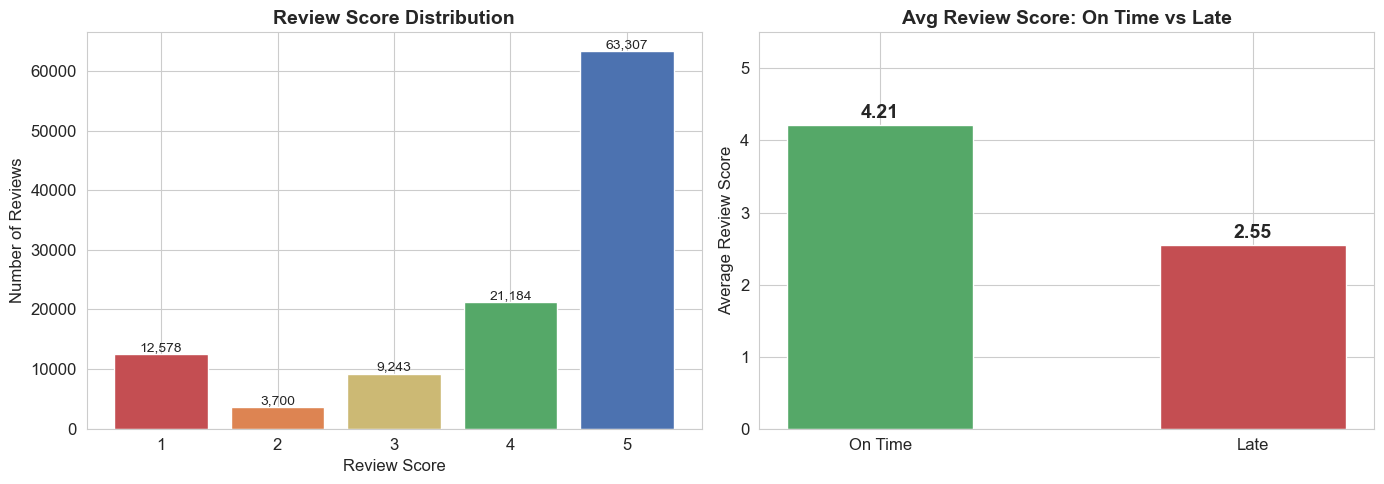

In [10]:
# Review score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
score_counts = df['review_score'].value_counts().sort_index()
colors = ['#C44E52', '#DD8452', '#CCB974', '#55A868', '#4C72B0']
axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Review Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])

for i, v in enumerate(score_counts.values):
    axes[0].text(score_counts.index[i], v + 500, f'{v:,}', ha='center', fontsize=10)

# Average score by delivery status
avg_by_late = df.groupby('is_late')['review_score'].mean()
bar_labels = ['On Time', 'Late']
bar_colors = ['#55A868', '#C44E52']
axes[1].bar(bar_labels, avg_by_late.values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('Avg Review Score: On Time vs Late', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Review Score')
axes[1].set_ylim(0, 5.5)

for i, v in enumerate(avg_by_late.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('customer_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

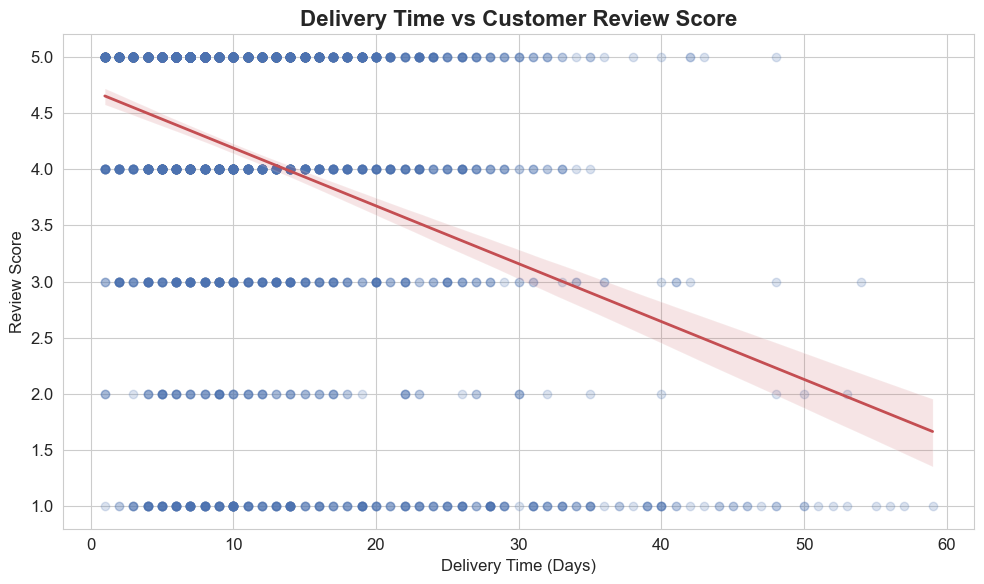

In [11]:
# Delivery time vs Review score (scatter with regression)
sample = df[df['delivery_days'].between(0, 60)].sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=sample, x='delivery_days', y='review_score', 
            scatter_kws={'alpha': 0.2, 'color': '#4C72B0'},
            line_kws={'color': '#C44E52', 'linewidth': 2},
            ax=ax)
ax.set_title('Delivery Time vs Customer Review Score', fontsize=16, fontweight='bold')
ax.set_xlabel('Delivery Time (Days)')
ax.set_ylabel('Review Score')

plt.tight_layout()
plt.savefig('delivery_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Key Findings & Recommendations

### Findings
1. **Revenue Growth:** Order volume and revenue showed strong growth from 2017 to 2018
2. **Delivery Impact:** Late deliveries significantly reduce customer satisfaction scores
3. **Regional Gaps:** Remote states experience 2-3x longer delivery times
4. **Review Patterns:** Most customers rate 5 stars when delivered on time

### Recommendations
1. **Prioritize delivery speed** in slow states — consider regional warehouses
2. **Set realistic delivery estimates** — customers rate worse when expectations aren't met
3. **Focus on top categories** — invest in inventory for highest-revenue product types
4. **Follow up with low-rating customers** — target orders with late delivery for recovery outreach